In [1157]:
import cv2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path().resolve().parent / 'data'
BBDD_DIR = DATA_DIR / 'BBDD'
QSD2 = DATA_DIR / 'qsd2_w2'

IMG = '00028'

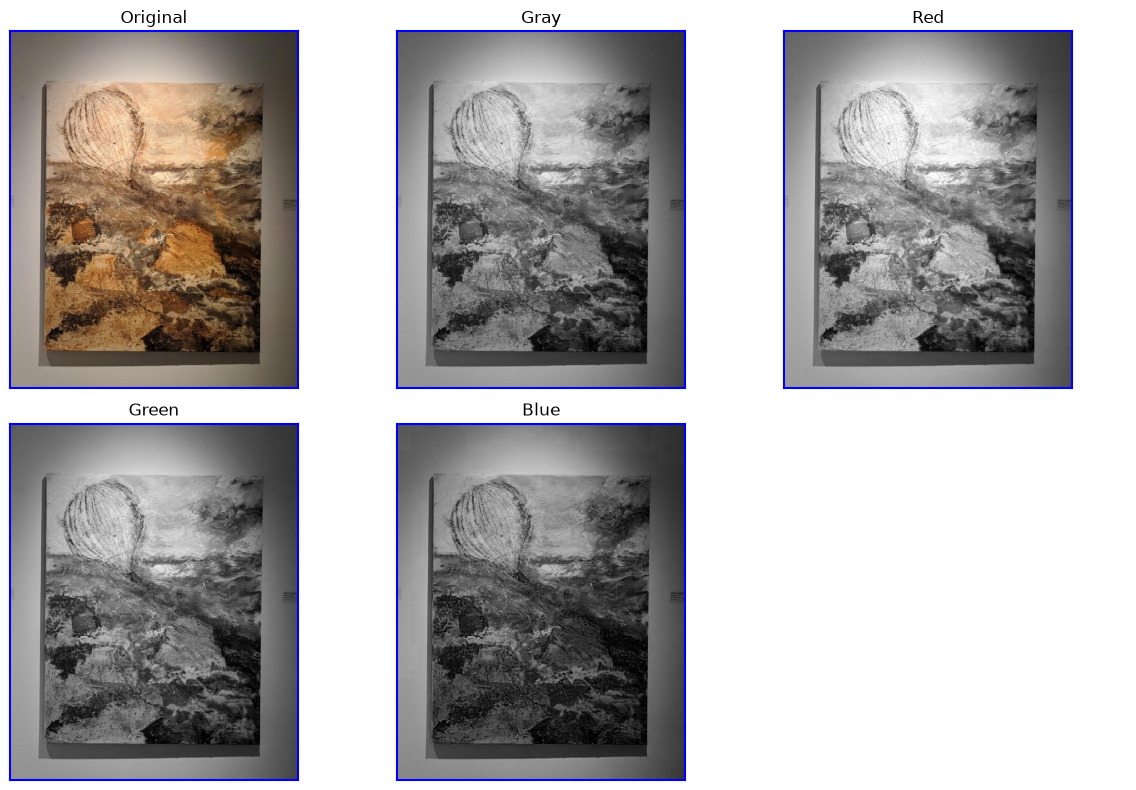

In [1158]:
img = cv2.imread(QSD2 / (IMG+'.jpg'))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def show(*images, titles=None, size=4, cols=3):
    cols = min(cols, len(images))
    rows = -(-len(images) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows), squeeze=False)
    for ax in axes.flat[len(images):]:
        ax.axis('off')
    for i, (ax, im) in enumerate(zip(axes.flat, images)):
        if im.ndim == 2:
            ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(im)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color('blue')
            spine.set_linewidth(1.5)
        if titles:
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()

def norm(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

def inv(img):
    return 255 - norm(img)

show(img, gray, r, g, b, titles=['Original', 'Gray', 'Red', 'Green', 'Blue'])

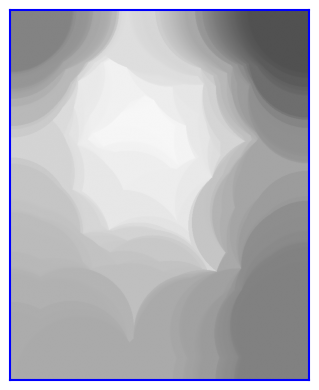

In [1159]:
h, w = gray.shape
n = int(min(h,w)//2.5)
n = n + 1 if n % 2 == 0 else n
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n,n))

closed = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)
show(closed)

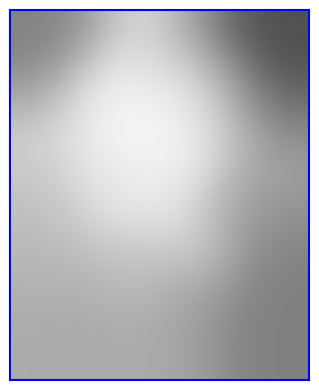

In [1160]:
n = int(min(h,w)//2)
n = n + 1 if n % 2 == 0 else n

closed = cv2.GaussianBlur(closed, (n, n), 0)
show(closed)

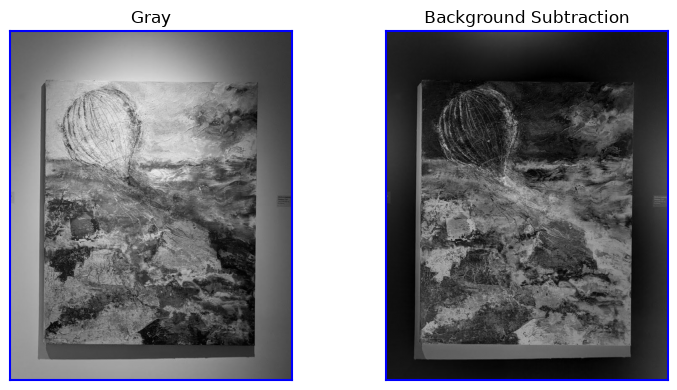

In [1161]:
diff = cv2.absdiff(gray, closed)
closed = diff
show(gray, closed, titles=['Gray', 'Background Subtraction'])

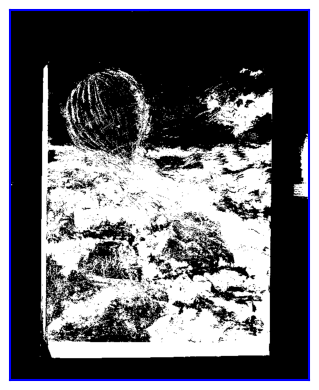

In [1162]:
t, thr = cv2.threshold(closed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# thr = cv2.adaptiveThreshold(closed, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
# thr = inv(thr)
show(norm(thr))

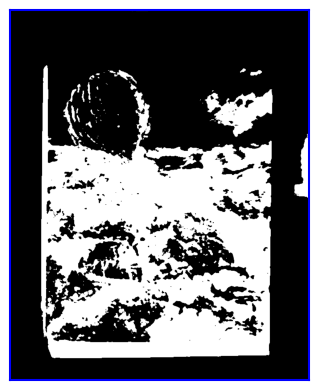

In [1163]:
mask = cv2.medianBlur(thr, 5)
show(mask)

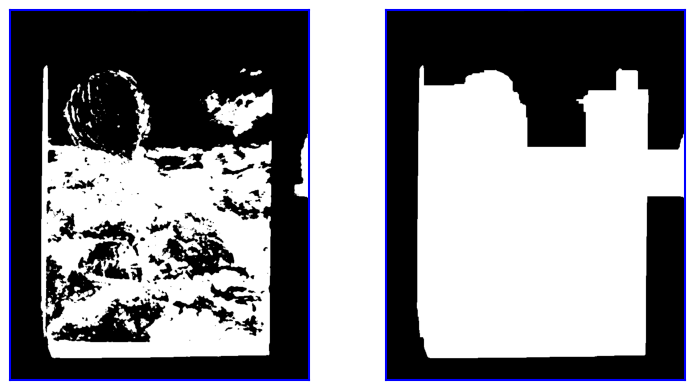

In [1164]:
h, w = gray.shape
n = min(h,w)//10
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (n,n))
mask1 = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
show(mask, mask1)

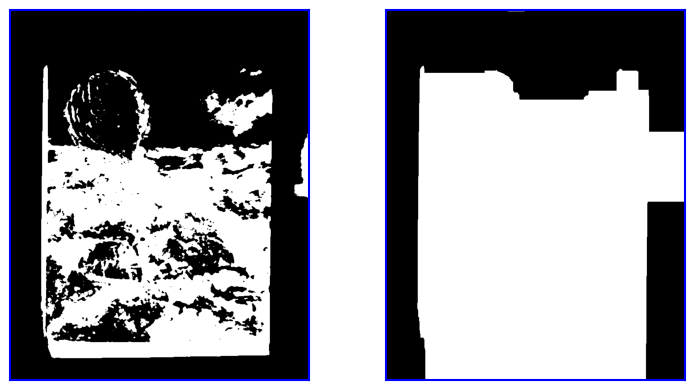

In [1165]:
h, w = gray.shape
n = min(h,w)//5
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (n,n))
mask1 = cv2.morphologyEx(mask1, cv2.MORPH_CLOSE, kernel)
show(mask, mask1)

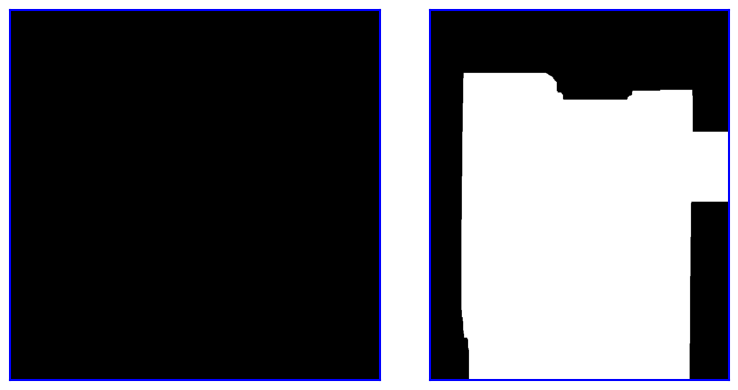

In [1166]:
n = int(min(h,w)/10)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (n,n))
mask = cv2.morphologyEx(mask1, cv2.MORPH_OPEN, kernel)
show(norm(kernel), mask)

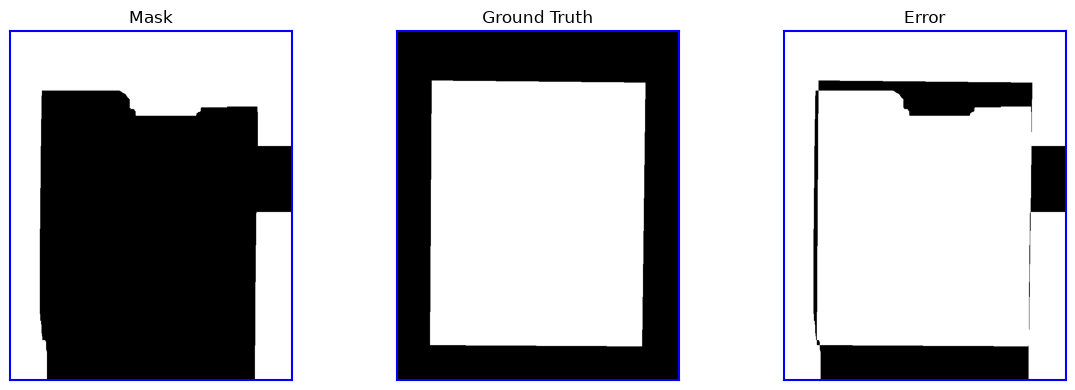

In [1167]:
gt = cv2.imread(QSD2 / (IMG+'.png'), cv2.IMREAD_GRAYSCALE)

mask = inv(mask)
err = cv2.absdiff(mask, gt)

show(mask, gt, err, titles=['Mask', 'Ground Truth', 'Error'])